In [25]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
BASE_DIR = Path("../../results/processed_hrv")

clean_path = BASE_DIR / "basal_v2_clean.csv"
initial_diag_path = BASE_DIR / "initial_diagnostic.csv"
final_diag_path = BASE_DIR / "final_diagnostic.csv"
height_inc_path = BASE_DIR / "height_inconsistencies.csv"
bmi_inc_path = BASE_DIR / "bmi_inconsistencies.csv"
hr_rr_inc_path = BASE_DIR / "hr_rr_inconsistencies.csv"
range_flags_path = BASE_DIR / "range_flags.csv"
log_path = BASE_DIR / "processing_log.json"

OUT_DIR = BASE_DIR / "qc_outputs"
OUT_DIR.mkdir(exist_ok=True, parents=True)

In [27]:
df = pd.read_csv(clean_path)

initial_diag = pd.read_csv(initial_diag_path).rename(columns={"Unnamed: 0": "variable"})
final_diag = pd.read_csv(final_diag_path).rename(columns={"Unnamed: 0": "variable"})
height_inc = pd.read_csv(height_inc_path)
bmi_inc = pd.read_csv(bmi_inc_path)
hr_rr_inc = pd.read_csv(hr_rr_inc_path)
range_flags = pd.read_csv(range_flags_path)

with open(log_path, "r", encoding="utf-8") as f:
    processing_log = json.load(f)

print("Clean dataset shape:", df.shape)
print("Initial diagnostic shape:", initial_diag.shape)
print("Final diagnostic shape:", final_diag.shape)
print("Height inconsistencies:", height_inc.shape)
print("BMI inconsistencies:", bmi_inc.shape)
print("HR-RR inconsistencies:", hr_rr_inc.shape)
print("Range flags:", range_flags.shape)

Clean dataset shape: (530, 26)
Initial diagnostic shape: (20, 5)
Final diagnostic shape: (26, 5)
Height inconsistencies: (9, 6)
BMI inconsistencies: (8, 8)
HR-RR inconsistencies: (15, 4)
Range flags: (14, 50)


In [28]:
processing_log

{'dataset_name': 'Basal v2',
 'timestamp': '2026-03-12T17:16:25.381937',
 'input_file': '../../raw_data/Basal v2.xlsx',
 'initial_shape': {'n_rows': 530, 'n_cols': 20},
 'steps': [{'step': 'drop_fully_empty_columns',
   'description': 'Removed columns containing only missing values.',
   'details': {'dropped_columns': ['Unnamed: 0',
     'Unnamed: 1',
     'redcap_repeat_instrument'],
    'n_dropped': 3}},
  {'step': 'rename_columns',
   'description': 'Renamed columns for consistency and easier downstream processing.',
   'details': {'rename_map': {'weight kg': 'weight_kg',
     'height cm': 'height_cm',
     'height mt': 'height_m'}}},
  {'step': 'clean_object_numeric_strings',
   'description': 'Applied generic malformed numeric-string cleaning to object columns.',
   'details': {'object_columns_cleaned': ['t2m_pre_rmssd']}},
  {'step': 'force_numeric_conversion',
   'description': 'Forced selected variables to numeric type using coercion.',
   'details': {'numeric_columns': ['sex',

In [29]:
initial_missing = initial_diag.sort_values(["missing_pct", "missing_n"], ascending=[False, False]).reset_index(drop=True)
initial_missing

,variable,dtype_raw,missing_n,missing_pct,n_unique
0,Unnamed: 0,float64,530,100.00,0
1,Unnamed: 1,float64,530,100.00,0
2,redcap_repeat_instrument,float64,530,100.00,0
3,t2m_pre_sdnn,float64,11,2.08,268
4,t2m_pre_rmssd,object,8,1.51,278
5,t2m_pre_mean_hr,float64,1,0.19,55
6,t2m_pre_mean_rr,float64,0,0.00,303
7,bp_pam,float64,0,0.00,134
8,imc,float64,0,0.00,418
9,weight kg,float64,0,0.00,210


In [30]:
final_missing = final_diag.sort_values(["missing_pct", "missing_n"], ascending=[False, False]).reset_index(drop=True)
final_missing

,variable,dtype_final,missing_n,missing_pct,n_unique
0,t2m_pre_sdnn,float64,11,2.08,268
1,t2m_pre_rmssd,float64,8,1.51,215
2,t2m_pre_mean_hr,float64,1,0.19,55
3,height_inconsistent,bool,0,0.00,2
4,imc_inconsistent,bool,0,0.00,2
5,hr_rr_inconsistent,bool,0,0.00,2
6,weight_kg,float64,0,0.00,210
7,height_cm_final,float64,0,0.00,40
8,height_m_final,float64,0,0.00,40
9,imc_final,float64,0,0.00,411


In [31]:
missing_compare = (
    initial_diag[["variable", "missing_n", "missing_pct"]]
    .merge(
        final_diag[["variable", "missing_n", "missing_pct"]],
        on="variable",
        how="outer",
        suffixes=("_initial", "_final")
    )
    .sort_values(["missing_pct_initial", "missing_pct_final"], ascending=[False, False])
    .reset_index(drop=True)
)

missing_compare

,variable,missing_n_initial,missing_pct_initial,missing_n_final,missing_pct_final
0,Unnamed: 0,530.0,100.00,NaN,NaN
1,Unnamed: 1,530.0,100.00,NaN,NaN
2,redcap_repeat_instrument,530.0,100.00,NaN,NaN
3,t2m_pre_sdnn,11.0,2.08,11.0,2.08
4,t2m_pre_rmssd,8.0,1.51,8.0,1.51
5,t2m_pre_mean_hr,1.0,0.19,1.0,0.19
6,age,0.0,0.00,0.0,0.00
7,bp_diastolic,0.0,0.00,0.0,0.00
8,bp_pam,0.0,0.00,0.0,0.00
9,bp_pp,0.0,0.00,0.0,0.00


In [32]:
variable_groups = {
    "Demographic": ["sex", "age"],
    "Anthropometric": ["weight_kg", "height_cm_final", "height_m_final", "imc_final"],
    "Blood pressure": ["bp_systolic", "bp_diastolic", "bp_pam", "bp_pp", "bp_pp_recomputed", "bp_pam_recomputed"],
    "HRV": [
        "t2m_pre_mean_rr", "t2m_pre_mean_hr", "t2m_pre_sdnn", "t2m_pre_rmssd",
        "t2m_pre_hf", "t2m_pre_lf", "t2m_pre_vlf", "mean_hr_from_rr"
    ],
    "Quality control": [
        "height_inconsistent", "imc_inconsistent", "hr_rr_inconsistent",
        "n_integrity_flags", "n_range_flags", "n_total_qc_flags"
    ]
}

variable_group_df = pd.DataFrame(
    [(group, var) for group, vars_ in variable_groups.items() for var in vars_],
    columns=["group", "variable"]
)

variable_group_df

,group,variable
0,Demographic,sex
1,Demographic,age
2,Anthropometric,weight_kg
3,Anthropometric,height_cm_final
4,Anthropometric,height_m_final
5,Anthropometric,imc_final
6,Blood pressure,bp_systolic
7,Blood pressure,bp_diastolic
8,Blood pressure,bp_pam
9,Blood pressure,bp_pp


In [33]:
inconsistency_summary = pd.DataFrame({
    "check": [
        "Height consistency (height_cm vs height_m)",
        "BMI consistency (recorded vs recomputed)",
        "HR-RR consistency (recorded HR vs HR from RR)"
    ],
    "n_flagged_rows": [
        len(height_inc),
        len(bmi_inc),
        len(hr_rr_inc)
    ],
    "percentage_of_dataset": [
        len(height_inc) / len(df) * 100,
        len(bmi_inc) / len(df) * 100,
        len(hr_rr_inc) / len(df) * 100
    ]
})

inconsistency_summary["percentage_of_dataset"] = inconsistency_summary["percentage_of_dataset"].round(2)
inconsistency_summary

,check,n_flagged_rows,percentage_of_dataset
0,Height consistency (height_cm vs height_m),9,1.70
1,BMI consistency (recorded vs recomputed),8,1.51
2,HR-RR consistency (recorded HR vs HR from RR),15,2.83


In [34]:
print("Height inconsistencies")
display(height_inc.head(10))

print("BMI inconsistencies")
display(bmi_inc.head(10))

print("HR-RR inconsistencies")
display(hr_rr_inc.head(10))

Height inconsistencies


,height_cm,height_m,height_m_from_cm,height_diff_m,weight_kg,imc
0,148,1.51,1.48,0.03,67.0,29.384676
1,175,1.51,1.75,0.24,65.2,28.595237
2,145,1.51,1.45,0.06,69.8,30.612692
3,148,1.51,1.48,0.03,68.2,29.910969
4,150,1.51,1.50,0.01,68.2,29.910969
5,155,1.51,1.55,0.04,74.1,32.498575
6,149,1.51,1.49,0.02,64.9,28.463664
7,149,1.51,1.49,0.02,59.7,26.183062
8,155,1.51,1.55,0.04,78.1,34.252884


BMI inconsistencies


,weight_kg,height_cm,height_m,height_cm_final,height_m_final,imc,imc_recomputed_final,imc_diff_final
0,67.0,148,1.51,148.0,1.48,29.384676,30.588020,1.203344
1,65.2,175,1.51,175.0,1.75,28.595237,21.289796,7.305441
2,69.8,145,1.51,145.0,1.45,30.612692,33.198573,2.585881
3,68.2,148,1.51,148.0,1.48,29.910969,31.135866,1.224897
4,74.1,155,1.51,155.0,1.55,32.498575,30.842872,1.655703
5,64.9,149,1.51,149.0,1.49,28.463664,29.232917,0.769254
6,59.7,149,1.51,149.0,1.49,26.183062,26.890681,0.707618
7,78.1,155,1.51,155.0,1.55,34.252884,32.507804,1.745079


HR-RR inconsistencies


,t2m_pre_mean_rr,t2m_pre_mean_hr,mean_hr_from_rr,mean_hr_rr_diff
0,100.0,60.0,600.000000,540.000000
1,1036.0,104.0,57.915058,46.084942
2,1014.0,56.0,59.171598,3.171598
3,68.0,88.0,882.352941,794.352941
4,106.0,57.0,566.037736,509.037736
5,100.0,60.0,600.000000,540.000000
6,600.0,10.0,100.000000,90.000000
7,106.0,57.0,566.037736,509.037736
8,105.0,57.0,571.428571,514.428571
9,85.8,70.0,699.300699,629.300699


In [35]:
range_step = [s for s in processing_log["steps"] if s["step"] == "physiological_range_checks"][0]

range_flag_counts = pd.DataFrame(
    list(range_step["details"]["flag_counts"].items()),
    columns=["flag", "count"]
).sort_values("count", ascending=False).reset_index(drop=True)

range_flag_counts

,flag,count
0,t2m_pre_mean_rr_out_of_range,10
1,t2m_pre_sdnn_out_of_range,3
2,t2m_pre_mean_hr_out_of_range,1
3,age_out_of_range,0
4,imc_final_out_of_range,0
5,weight_kg_out_of_range,0
6,height_cm_final_out_of_range,0
7,height_m_final_out_of_range,0
8,bp_pam_out_of_range,0
9,bp_diastolic_out_of_range,0


In [36]:
qc_summary = pd.DataFrame({
    "metric": [
        "Rows with any integrity flag",
        "Rows with any range flag",
        "Rows with any QC flag",
        "Rows with 0 QC flags",
        "Rows with 1 QC flag",
        "Rows with 2 QC flags"
    ],
    "value": [
        int((df["n_integrity_flags"] > 0).sum()),
        int((df["n_range_flags"] > 0).sum()),
        int((df["n_total_qc_flags"] > 0).sum()),
        int((df["n_total_qc_flags"] == 0).sum()),
        int((df["n_total_qc_flags"] == 1).sum()),
        int((df["n_total_qc_flags"] == 2).sum()),
    ]
})

qc_summary["percentage"] = (qc_summary["value"] / len(df) * 100).round(2)
qc_summary

,metric,value,percentage
0,Rows with any integrity flag,24,4.53
1,Rows with any range flag,14,2.64
2,Rows with any QC flag,27,5.09
3,Rows with 0 QC flags,503,94.91
4,Rows with 1 QC flag,8,1.51
5,Rows with 2 QC flags,19,3.58


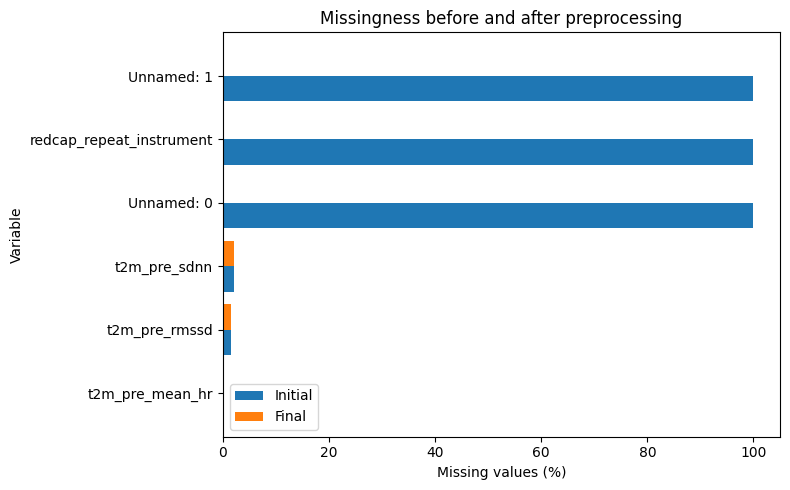

In [37]:
plot_df = missing_compare.fillna(0).copy()

plot_df = plot_df[
    (plot_df["missing_pct_initial"] > 0) | (plot_df["missing_pct_final"] > 0)
].copy()

plot_df = plot_df.sort_values("missing_pct_initial", ascending=True)

plt.figure(figsize=(8, 5))
y = np.arange(len(plot_df))

plt.barh(y - 0.2, plot_df["missing_pct_initial"], height=0.4, label="Initial")
plt.barh(y + 0.2, plot_df["missing_pct_final"], height=0.4, label="Final")

plt.yticks(y, plot_df["variable"])
plt.xlabel("Missing values (%)")
plt.ylabel("Variable")
plt.title("Missingness before and after preprocessing")
plt.legend()
plt.tight_layout()

plt.savefig(OUT_DIR / "missingness_initial_vs_final.png", dpi=300, bbox_inches="tight")
plt.show()

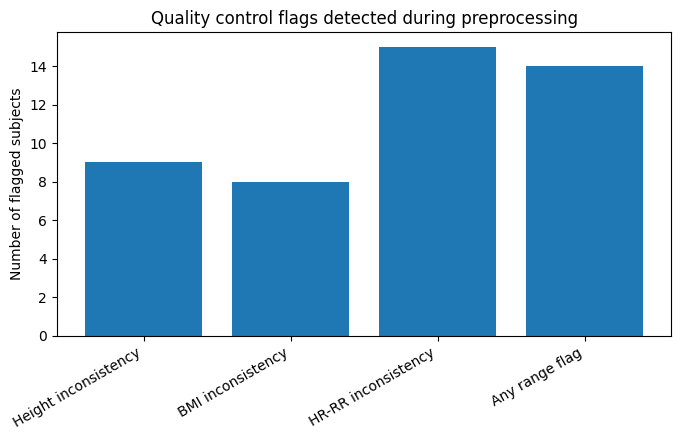

In [38]:
plot_incons = pd.DataFrame({
    "category": [
        "Height inconsistency",
        "BMI inconsistency",
        "HR-RR inconsistency",
        "Any range flag"
    ],
    "count": [
        len(height_inc),
        len(bmi_inc),
        len(hr_rr_inc),
        len(range_flags)
    ]
})

plt.figure(figsize=(7, 4.5))
plt.bar(plot_incons["category"], plot_incons["count"])
plt.ylabel("Number of flagged subjects")
plt.title("Quality control flags detected during preprocessing")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(OUT_DIR / "qc_flags_summary.png", dpi=300, bbox_inches="tight")
plt.show()

In [39]:
qc_distribution = (
    df["n_total_qc_flags"]
    .value_counts()
    .sort_index()
    .rename_axis("n_total_qc_flags")
    .reset_index(name="n_subjects")
)

qc_distribution["percentage"] = (qc_distribution["n_subjects"] / len(df) * 100).round(2)
qc_distribution

,n_total_qc_flags,n_subjects,percentage
0,0,503,94.91
1,1,8,1.51
2,2,19,3.58


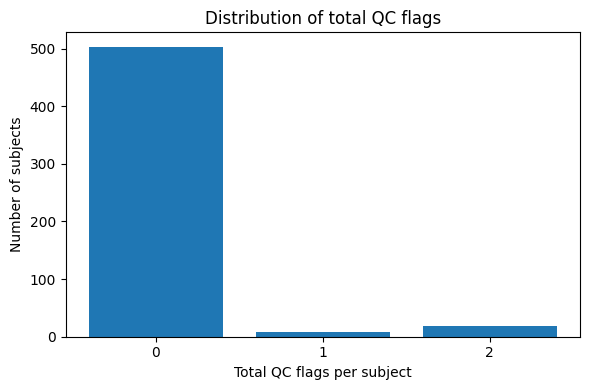

In [40]:
plt.figure(figsize=(6, 4))
plt.bar(qc_distribution["n_total_qc_flags"].astype(str), qc_distribution["n_subjects"])
plt.xlabel("Total QC flags per subject")
plt.ylabel("Number of subjects")
plt.title("Distribution of total QC flags")
plt.tight_layout()

plt.savefig(OUT_DIR / "qc_flag_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [41]:
qc_summary = pd.DataFrame({
    "metric": [
        "Rows with any integrity flag",
        "Rows with any range flag",
        "Rows with any QC flag",
        "Rows with 0 QC flags",
        "Rows with 1 QC flag",
        "Rows with 2 QC flags"
    ],
    "value": [
        int((df["n_integrity_flags"] > 0).sum()),
        int((df["n_range_flags"] > 0).sum()),
        int((df["n_total_qc_flags"] > 0).sum()),
        int((df["n_total_qc_flags"] == 0).sum()),
        int((df["n_total_qc_flags"] == 1).sum()),
        int((df["n_total_qc_flags"] == 2).sum()),
    ]
})

qc_summary["percentage"] = (qc_summary["value"] / len(df) * 100).round(2)
qc_summary

,metric,value,percentage
0,Rows with any integrity flag,24,4.53
1,Rows with any range flag,14,2.64
2,Rows with any QC flag,27,5.09
3,Rows with 0 QC flags,503,94.91
4,Rows with 1 QC flag,8,1.51
5,Rows with 2 QC flags,19,3.58


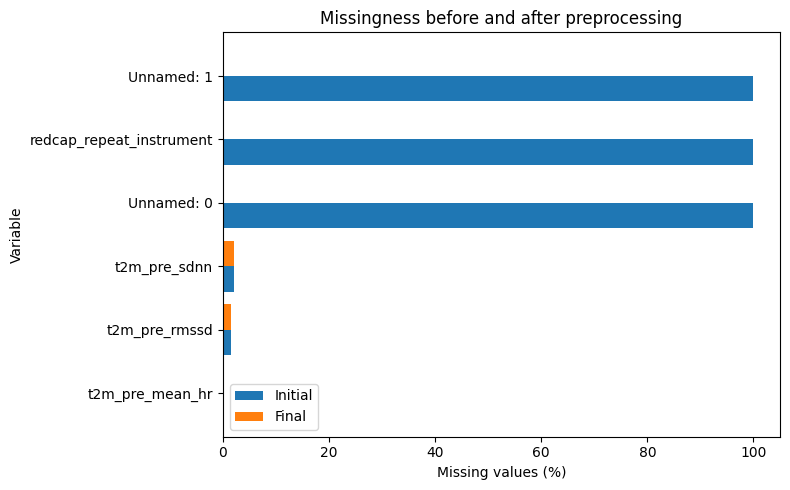

In [42]:
plot_df = missing_compare.fillna(0).copy()

plot_df = plot_df[
    (plot_df["missing_pct_initial"] > 0) | (plot_df["missing_pct_final"] > 0)
].copy()

plot_df = plot_df.sort_values("missing_pct_initial", ascending=True)

plt.figure(figsize=(8, 5))
y = np.arange(len(plot_df))

plt.barh(y - 0.2, plot_df["missing_pct_initial"], height=0.4, label="Initial")
plt.barh(y + 0.2, plot_df["missing_pct_final"], height=0.4, label="Final")

plt.yticks(y, plot_df["variable"])
plt.xlabel("Missing values (%)")
plt.ylabel("Variable")
plt.title("Missingness before and after preprocessing")
plt.legend()
plt.tight_layout()

plt.savefig(OUT_DIR / "missingness_initial_vs_final.png", dpi=300, bbox_inches="tight")
plt.show()

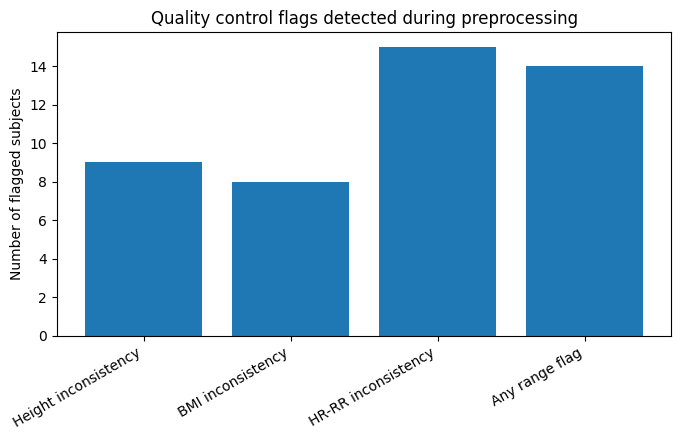

In [43]:
plot_incons = pd.DataFrame({
    "category": [
        "Height inconsistency",
        "BMI inconsistency",
        "HR-RR inconsistency",
        "Any range flag"
    ],
    "count": [
        len(height_inc),
        len(bmi_inc),
        len(hr_rr_inc),
        len(range_flags)
    ]
})

plt.figure(figsize=(7, 4.5))
plt.bar(plot_incons["category"], plot_incons["count"])
plt.ylabel("Number of flagged subjects")
plt.title("Quality control flags detected during preprocessing")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(OUT_DIR / "qc_flags_summary.png", dpi=300, bbox_inches="tight")
plt.show()

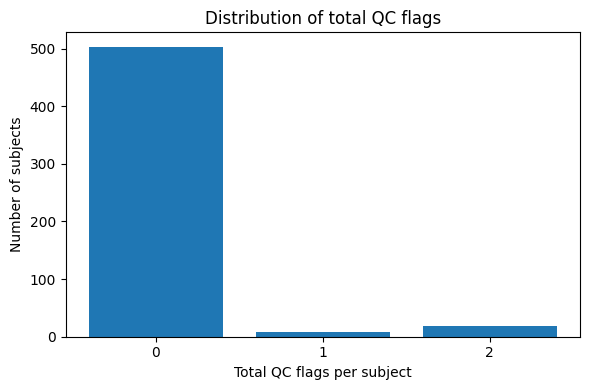

In [44]:
plt.figure(figsize=(6, 4))
plt.bar(qc_distribution["n_total_qc_flags"].astype(str), qc_distribution["n_subjects"])
plt.xlabel("Total QC flags per subject")
plt.ylabel("Number of subjects")
plt.title("Distribution of total QC flags")
plt.tight_layout()

plt.savefig(OUT_DIR / "qc_flag_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [45]:
manuscript_table_qc = pd.DataFrame({
    "Indicator": [
        "Initial dataset size",
        "Final dataset size",
        "Removed fully empty columns",
        "Duplicate rows",
        "Fully missing rows",
        "Rows with height inconsistency",
        "Rows with BMI inconsistency",
        "Rows with HR-RR inconsistency",
        "Rows with any physiological range flag",
        "Rows with any QC flag"
    ],
    "Value": [
        f"{initial_rows} rows × {initial_cols} columns",
        f"{final_rows} rows × {final_cols} columns",
        step_drop["details"]["n_dropped"],
        step_row_checks["details"]["duplicate_rows"],
        step_row_checks["details"]["fully_missing_rows"],
        len(height_inc),
        len(bmi_inc),
        len(hr_rr_inc),
        len(range_flags),
        int((df["n_total_qc_flags"] > 0).sum())
    ],
    "Percentage of cohort": [
        "",
        "",
        "",
        "0.00",
        "0.00",
        f"{len(height_inc) / len(df) * 100:.2f}",
        f"{len(bmi_inc) / len(df) * 100:.2f}",
        f"{len(hr_rr_inc) / len(df) * 100:.2f}",
        f"{len(range_flags) / len(df) * 100:.2f}",
        f"{(df['n_total_qc_flags'] > 0).sum() / len(df) * 100:.2f}"
    ]
})

manuscript_table_qc

,Indicator,Value,Percentage of cohort
0,Initial dataset size,530 rows × 20 columns,
1,Final dataset size,530 rows × 26 columns,
2,Removed fully empty columns,3,
3,Duplicate rows,0,0.00
4,Fully missing rows,0,0.00
5,Rows with height inconsistency,9,1.70
6,Rows with BMI inconsistency,8,1.51
7,Rows with HR-RR inconsistency,15,2.83
8,Rows with any physiological range flag,14,2.64
9,Rows with any QC flag,27,5.09


In [46]:
# --- Basic metadata from processing log ---
initial_rows = processing_log["initial_shape"]["n_rows"]
initial_cols = processing_log["initial_shape"]["n_cols"]
final_rows = processing_log["final_shape"]["n_rows"]
final_cols = processing_log["final_shape"]["n_cols"]

# --- Retrieve processing steps by name ---
steps_by_name = {step["step"]: step for step in processing_log["steps"]}

step_drop = steps_by_name.get("drop_fully_empty_columns", {})
step_rename = steps_by_name.get("rename_columns", {})
step_clean_obj = steps_by_name.get("clean_object_columns", {})
step_row_checks = steps_by_name.get("row_integrity_checks", {})
step_range = steps_by_name.get("physiological_range_checks", {})

# --- Safe extraction of dropped columns ---
dropped_columns_list = step_drop.get("details", {}).get("dropped_columns", [])
dropped_columns = pd.DataFrame({
    "dropped_column": dropped_columns_list
})

# --- Safe extraction of renamed columns ---
rename_dict = step_rename.get("details", {}).get("rename_map", {})
rename_map = pd.DataFrame(
    list(rename_dict.items()),
    columns=["original_name", "new_name"]
)

# --- Safe extraction of cleaned object columns ---
object_cols_cleaned_list = step_clean_obj.get("details", {}).get("object_columns_cleaned", [])
object_cols_cleaned = pd.DataFrame({
    "object_column_cleaned": object_cols_cleaned_list
})

# --- Quick check ---
print("Dropped columns:")
display(dropped_columns)

print("Renamed columns:")
display(rename_map)

print("Object columns cleaned:")
display(object_cols_cleaned)

Dropped columns:


,dropped_column
0,Unnamed: 0
1,Unnamed: 1
2,redcap_repeat_instrument


Renamed columns:


,original_name,new_name
0,weight kg,weight_kg
1,height cm,height_cm
2,height mt,height_m


Object columns cleaned:


,object_column_cleaned


In [47]:
summary_general = pd.DataFrame({
    "metric": [
        "Initial number of rows",
        "Initial number of columns",
        "Final number of rows",
        "Final number of columns",
        "Dropped fully empty columns",
        "Duplicate rows",
        "Fully missing rows",
        "Rows with any range flag",
        "Height inconsistencies",
        "BMI inconsistencies",
        "HR-RR inconsistencies"
    ],
    "value": [
        initial_rows,
        initial_cols,
        final_rows,
        final_cols,
        len(dropped_columns),
        step_row_checks.get("details", {}).get("duplicate_rows", 0),
        step_row_checks.get("details", {}).get("fully_missing_rows", 0),
        len(range_flags),
        len(height_inc),
        len(bmi_inc),
        len(hr_rr_inc),
    ]
})

summary_general

,metric,value
0,Initial number of rows,530
1,Initial number of columns,20
2,Final number of rows,530
3,Final number of columns,26
4,Dropped fully empty columns,3
5,Duplicate rows,0
6,Fully missing rows,0
7,Rows with any range flag,14
8,Height inconsistencies,9
9,BMI inconsistencies,8


In [48]:
summary_general.to_csv(OUT_DIR / "summary_general.csv", index=False)
dropped_columns.to_csv(OUT_DIR / "dropped_columns.csv", index=False)
rename_map.to_csv(OUT_DIR / "rename_map.csv", index=False)
object_cols_cleaned.to_csv(OUT_DIR / "object_columns_cleaned.csv", index=False)
initial_missing.to_csv(OUT_DIR / "initial_missingness.csv", index=False)
final_missing.to_csv(OUT_DIR / "final_missingness.csv", index=False)
missing_compare.to_csv(OUT_DIR / "missingness_comparison.csv", index=False)
variable_group_df.to_csv(OUT_DIR / "final_variable_groups.csv", index=False)
inconsistency_summary.to_csv(OUT_DIR / "inconsistency_summary.csv", index=False)
range_flag_counts.to_csv(OUT_DIR / "range_flag_counts.csv", index=False)
qc_distribution.to_csv(OUT_DIR / "qc_distribution.csv", index=False)
qc_summary.to_csv(OUT_DIR / "qc_summary.csv", index=False)
manuscript_table_qc.to_csv(OUT_DIR / "manuscript_table_qc.csv", index=False)

print("QC outputs exported to:", OUT_DIR)

QC outputs exported to: ../../results/processed_hrv/qc_outputs


In [49]:
latex_table = manuscript_table_qc.to_latex(index=False, escape=False)
print(latex_table)

\begin{tabular}{lll}
\toprule
Indicator & Value & Percentage of cohort \\
\midrule
Initial dataset size & 530 rows × 20 columns &  \\
Final dataset size & 530 rows × 26 columns &  \\
Removed fully empty columns & 3 &  \\
Duplicate rows & 0 & 0.00 \\
Fully missing rows & 0 & 0.00 \\
Rows with height inconsistency & 9 & 1.70 \\
Rows with BMI inconsistency & 8 & 1.51 \\
Rows with HR-RR inconsistency & 15 & 2.83 \\
Rows with any physiological range flag & 14 & 2.64 \\
Rows with any QC flag & 27 & 5.09 \\
\bottomrule
\end{tabular}

